In [435]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [436]:
import os
os.makedirs("../Charts", exist_ok=True)
import warnings
warnings.filterwarnings("ignore")

Data Loading, Merging & Deep Exploration

In [437]:
train_df=pd.read_csv('../Dataset/train.csv')

In [438]:
train_df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [439]:
train_df["Order Date"]=pd.to_datetime(train_df["Order Date"],format='mixed')
train_df["Ship Date"]=pd.to_datetime(train_df["Ship Date"],format='mixed')


In [440]:
# Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season
train_df["Ordered Year"]=train_df["Order Date"].dt.year
train_df["Ordered Month"]=train_df["Order Date"].dt.month
train_df["Ordered Week Number"]=train_df["Order Date"].dt.isocalendar().week.astype(int)
train_df["Ordered Day of Week"]=train_df["Order Date"].dt.dayofweek
train_df["Ordered Quarter"] = train_df["Order Date"].dt.quarter

In [441]:
train_df["Shiped Year"]=train_df["Ship Date"].dt.year
train_df["Shiped Month"]=train_df["Ship Date"].dt.month
train_df["Shiped week Number"]=train_df["Ship Date"].dt.isocalendar().week.astype(int)
train_df["Shiped Day of Week"]=train_df["Ship Date"].dt.dayofweek
train_df["Shiped quarter"]=train_df["Ship Date"].dt.quarter

In [442]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:  # 9, 10, 11
        return "Autumn"

train_df["Ordered Season"] = train_df["Ordered Month"].apply(get_season)
train_df["Shipped Season"] = train_df["Shiped Month"].apply(get_season)

In [443]:
# Check for missing values, duplicates, and data type issues
train_df.isnull().sum()

Row ID                  0
Order ID                0
Order Date              0
Ship Date               0
Ship Mode               0
Customer ID             0
Customer Name           0
Segment                 0
Country                 0
City                    0
State                   0
Postal Code            11
Region                  0
Product ID              0
Category                0
Sub-Category            0
Product Name            0
Sales                   0
Ordered Year            0
Ordered Month           0
Ordered Week Number     0
Ordered Day of Week     0
Ordered Quarter         0
Shiped Year             0
Shiped Month            0
Shiped week Number      0
Shiped Day of Week      0
Shiped quarter          0
Ordered Season          0
Shipped Season          0
dtype: int64

In [444]:
(train_df["Postal Code"].isnull().sum()/len(train_df))

np.float64(0.0011224489795918367)

In [445]:
train_df["Postal Code"] = train_df["Postal Code"].fillna(train_df["Postal Code"].mode()[0])

In [446]:
train_df.duplicated().sum()

np.int64(0)

In [447]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Row ID               9800 non-null   int64         
 1   Order ID             9800 non-null   object        
 2   Order Date           9800 non-null   datetime64[ns]
 3   Ship Date            9800 non-null   datetime64[ns]
 4   Ship Mode            9800 non-null   object        
 5   Customer ID          9800 non-null   object        
 6   Customer Name        9800 non-null   object        
 7   Segment              9800 non-null   object        
 8   Country              9800 non-null   object        
 9   City                 9800 non-null   object        
 10  State                9800 non-null   object        
 11  Postal Code          9800 non-null   float64       
 12  Region               9800 non-null   object        
 13  Product ID           9800 non-nul

In [448]:
train_df=train_df.set_index("Order Date")

In [449]:
weekly_sales = train_df["Sales"].resample("W").sum().reset_index()
weekly_sales

,Order Date,Sales
0,2015-01-04,2791.9390
1,2015-01-11,11129.8340
2,2015-01-18,9754.9230
3,2015-01-25,3092.5440
4,2015-02-01,2059.0140
...,...,...
204,2018-12-02,21565.0600
205,2018-12-09,7261.7420
206,2018-12-16,14181.0200
207,2018-12-23,19457.0680


In [450]:
monthly_sales=train_df["Sales"].resample("ME").sum()
monthly_sales

Order Date
2015-01-31    28828.2540
2015-02-28    12588.4840
2015-03-31    54027.6920
2015-04-30    24710.0160
2015-05-31    29520.4900
2015-06-30    29181.3346
2015-07-31    35194.5580
2015-08-31    37349.2655
2015-09-30    65956.3998
2015-10-31    34561.9470
2015-11-30    64369.4565
2015-12-31    63568.3107
2016-01-31    29347.3864
2016-02-29    20728.3520
2016-03-31    34489.6776
2016-04-30    38056.9685
2016-05-31    30761.5585
2016-06-30    28515.9082
2016-07-31    28573.3100
2016-08-31    49076.9300
2016-09-30    65352.9970
2016-10-31    31631.8890
2016-11-30    50009.1450
2016-12-31    52891.8832
2017-01-31    38048.1840
2017-02-28    48907.5900
2017-03-31    48990.1410
2017-04-30    42368.0480
2017-05-31    64836.2518
2017-06-30    37424.6810
2017-07-31    41761.9430
2017-08-31    45766.8144
2017-09-30    40692.3063
2017-10-31    52156.9580
2017-11-30    66392.5470
2017-12-31    72847.0855
2018-01-31    59767.0910
2018-02-28    48928.8334
2018-03-31    74748.6238
2018-04-30    

In [451]:
# Which product category generates the highest total revenue?
x=(train_df.groupby("Category")["Sales"].sum().sort_values(ascending=False).idxmax())
print(x)

Technology


In [452]:
pivot = train_df.pivot_table(
    values="Sales",
    index="Ordered Year",
    columns="Region",
    aggfunc="sum"
)

print(pivot)

Region            Central        East        South         West
Ordered Year                                                   
2015          102920.5206  127652.819  103374.9055  145907.9630
2016          102425.1724  153225.183   70076.0825  133709.5675
2017          145673.8800  178511.538   93535.9035  182471.2285
2018          141627.3402  210129.186  122164.5675  248130.9255


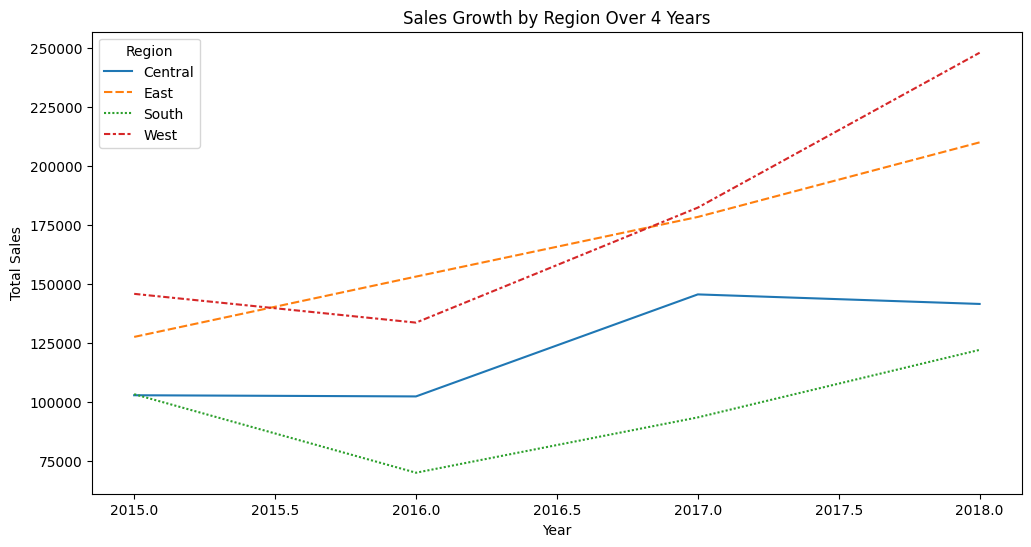

In [453]:
plt.figure(figsize=(12, 6))
sns.lineplot(pivot)
plt.title("Sales Growth by Region Over 4 Years")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.legend(title="Region")
plt.savefig("../Charts/sales_growth_by_region.png")
plt.show()


In [454]:
# What is the average time between Order Date and Ship Date — and does it vary by region?
train_df = train_df.reset_index()
train_df["Avg_Time"]=(train_df["Ship Date"]-train_df["Order Date"]).dt.days
avg_pivot=train_df.pivot_table(
    values="Avg_Time",
    index="Region",
    aggfunc="mean"
)
avg_pivot

,Avg_Time
Region,
Central,14.776899
East,8.671095
South,6.844806
West,6.894268


In [455]:
# # Are there months that consistently spike across all years (seasonality)?
month_data_pivot=train_df.pivot_table(
    index="Ordered Year",
    columns="Ordered Month",
    values="Sales",
    aggfunc="sum"
)
season_data_pivot=train_df.pivot_table(
    index="Ordered Year",
    columns="Ordered Season",
    values="Sales",
    aggfunc="sum"
)

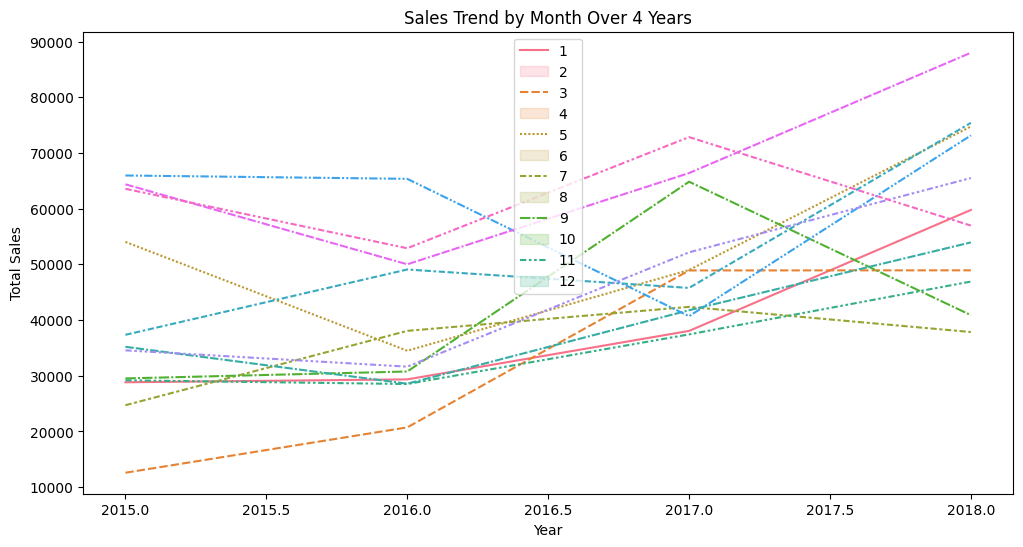

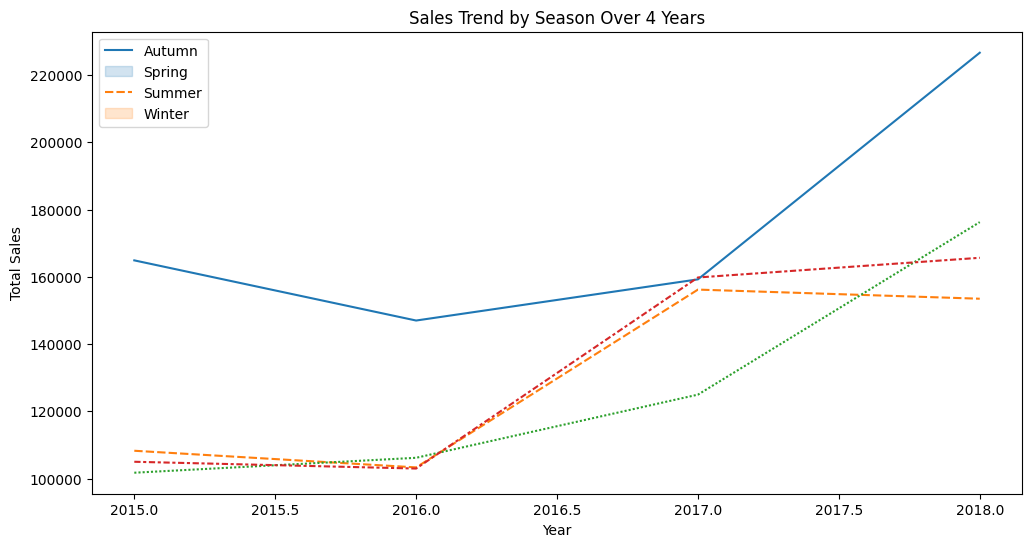

In [456]:
# Sales Trend by Month Over 4 Years
plt.figure(figsize=(12, 6))
sns.lineplot(month_data_pivot)
plt.legend(month_data_pivot.columns)
plt.title("Sales Trend by Month Over 4 Years")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.savefig("../Charts/sales_trend_by_month.png")
plt.show()

# Sales Trend by Season Over 4 Years
plt.figure(figsize=(12, 6))
sns.lineplot(season_data_pivot)
plt.legend(season_data_pivot.columns)
plt.title("Sales Trend by Season Over 4 Years")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.savefig("../Charts/sales_trend_by_season.png")
plt.show()


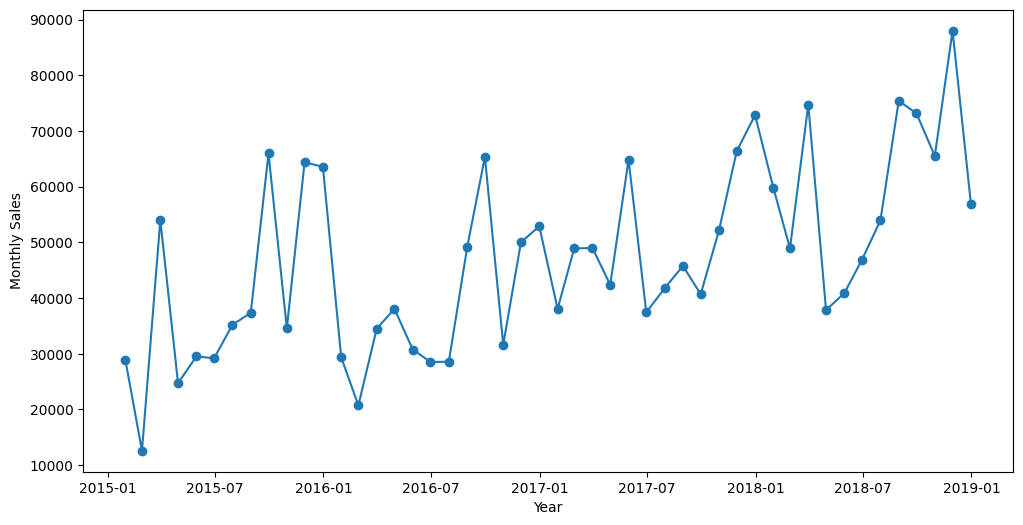

In [457]:
# Plot the overall monthly sales trend across all 4 years
plt.figure(figsize=(12,6))
plt.plot(monthly_sales,marker="o")
plt.xlabel("Year")
plt.ylabel("Monthly Sales")
plt.savefig("../Charts/mothly_sales_of_4years")
plt.show()

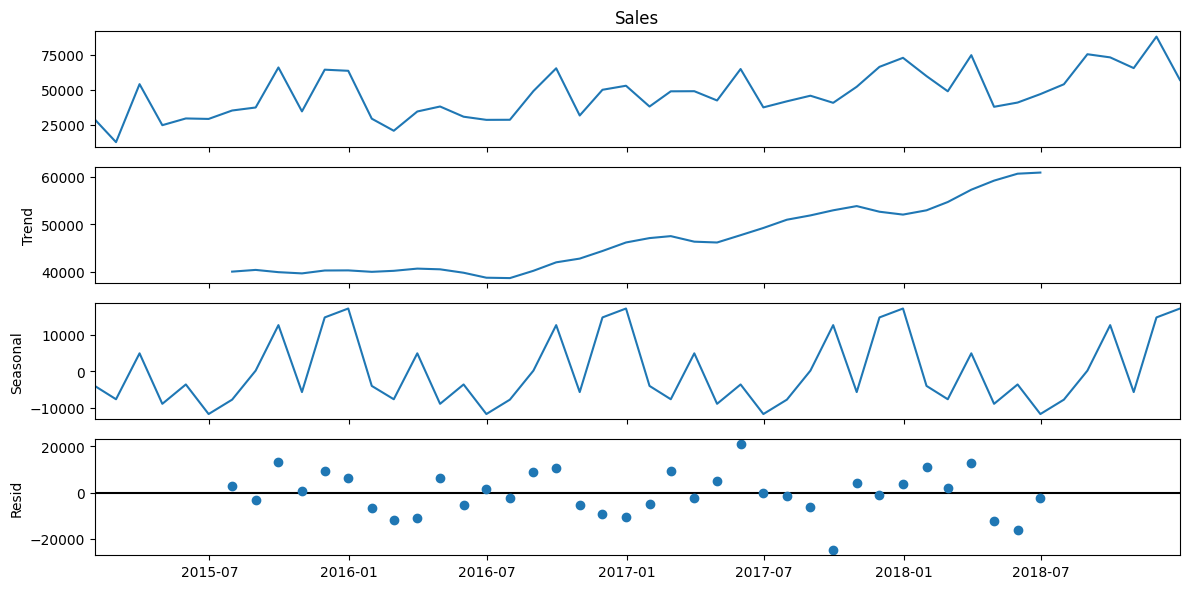

In [458]:
# Apply Time Series Decomposition
decomposition=seasonal_decompose(monthly_sales,model="additive",period=12)
# Plot all 4 components clearly on one figure
fig=decomposition.plot()
fig.set_size_inches(12,6)
fig.tight_layout()
plt.savefig("../Charts/Decomposition_Chart")
plt.show()

**Trend**
* Sales are increasing over time.
* Sales slight dip in 2016 but after that steadly increased.
* Overall sales increased in 4 years 


**Seasonal**
* Repeating peaks and valleys are present
* Repeating Patterns are present in seasonal therefore it's strong

In [459]:
# What months show the highest residual noise?
residual=decomposition.resid
HighNoise=residual.abs().sort_values(ascending=False)
HighNoise.head()

Order Date
2017-09-30    24836.903761
2017-05-31    20804.469074
2018-05-31    16073.642634
2015-09-30    13432.668114
2018-03-31    12620.363133
Name: resid, dtype: float64

In [460]:
residual.nlargest(5)

Order Date
2017-05-31    20804.469074
2015-09-30    13432.668114
2018-03-31    12620.363133
2018-01-31    10906.774964
2016-09-30    10760.926031
Name: resid, dtype: float64

In [461]:
residual.nsmallest(5)

Order Date
2017-09-30   -24836.903761
2018-05-31   -16073.642634
2018-04-30   -12339.858388
2016-02-29   -11755.776102
2016-03-31   -11050.621480
Name: resid, dtype: float64

<h3>ADF(Augmented Dickey-Fuller)Test</h3>

In [462]:
result=adfuller(monthly_sales)
if result[1]<0.05:
    print("Time series is Stationary, p_value is : ",result[1])
else:
     print("Time series is not stationary , p_value is : ",result[1])

Time series is not stationary , p_value is :  0.6967631967119422


* **Stationarity is a time series is stationary if its statistical properties do not change over time.**
<br><br>
* **This time series is not stationary**

In [463]:
monthly_dif=monthly_sales.diff().dropna()

In [464]:
retest_result=adfuller(monthly_dif)
if retest_result[1]<0.05:
    print("Time series is Stationary, p_value is : ",retest_result[1])
else:
     print("Time series is not stationary , p_value is : ",retest_result[1])


Time series is Stationary, p_value is :  0.0015327578233736367


<h2>Sales Forecasting using 3 Different Models</h2>

<h3> SARIMA (Statistical Model)</h3>

In [465]:
# Split monthly sales into test and train data
monthly_sales=train_df.set_index("Order Date")["Sales"].resample("ME").sum()
train=monthly_sales[:-12] 
test=monthly_sales[-12:]
test3=test[:3]

In [466]:
# Find best parameters for model
best_aic=float("inf")
best_order=None
seasonalOrder=None

for p in range(0,3):
    for q in range(0,3):
        for P in range(0,2):
            for Q in range(0,2):
                try: 
                    s_model=SARIMAX(
                        train,
                        order=(p,1,q),
                        seasonal_order=(P,1,Q,12)
                    ).fit(disp=False)
                    
                    if s_model.aic<best_aic:
                        best_aic=s_model.aic
                        best_order=(p,1,q)
                        seasonalOrder=(P,1,Q,12)
                except:
                    continue
print("Best Order :",best_order)
print("Best seasonal ordercv :",seasonalOrder)

Best Order : (0, 1, 1)
Best seasonal ordercv : (0, 1, 1, 12)


**Best order = (0,1,1)**
<br>
<br>
**Best Seasonal order = (0,1,1,12)**


In [467]:
s_model=SARIMAX(
    train,
    order=(0,1,1),
    seasonal_order=(0,1,1,12)
)
model_fitted=s_model.fit(disp=False)

In [468]:
print(model_fitted.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   36
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -252.364
Date:                            Tue, 14 Jul 2026   AIC                            510.727
Time:                                    12:21:07   BIC                            514.134
Sample:                                01-31-2015   HQIC                           511.584
                                     - 12-31-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.4237      0.196     -2.159      0.031      -0.808      -0.039
ma.S.L12      -0.6500      0.448   

In [469]:
# Generate a 3-month future forecast with confidence intervals
s_pred=model_fitted.forecast(steps=3)

In [470]:
# Validation
s_mse=mean_squared_error(test3,s_pred)
s_mae=mean_absolute_error(test3,s_pred)
s_mape=mean_absolute_percentage_error(test3,s_pred)

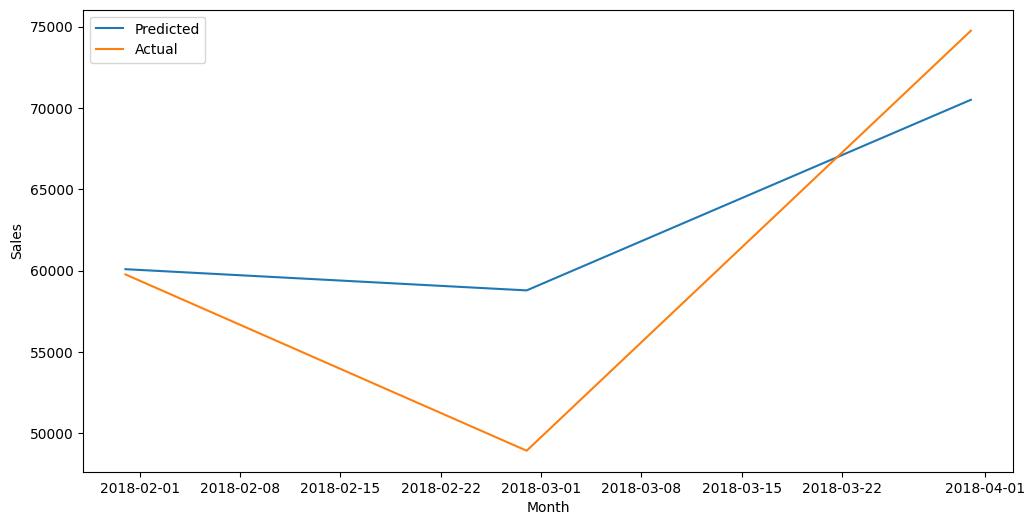

In [471]:
# Plot actual vs forecasted sales
plt.figure(figsize=(12,6))
plt.plot(s_pred,label="Predicted")
plt.plot(test3,label="Actual")
plt.legend()
plt.xlabel("Month")
plt.ylabel("Sales")
plt.savefig("../Predicted")

<h3> Facebook Prophet (Industry-standard Forecasting Tool)</h3>

In [472]:
# Prepare data in Prophet's required format (ds, y columns)
train_df["Order Date"]=pd.to_datetime(train_df["Order Date"])
monthly_sales=(train_df
               .set_index("Order Date")["Sales"]
               .resample("ME")
               .sum()
               .reset_index()
               )
monthly_sales.columns=["ds","y"]
p_train = monthly_sales[:-12]
p_test = monthly_sales[-12:]
p_test3=p_test[:3]


In [473]:
# Fit the model and generate a 3-month forecast
p_model=Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
p_model.fit(p_train)

12:21:07 - cmdstanpy - INFO - Chain [1] start processing
12:21:07 - cmdstanpy - INFO - Chain [1] done processing


In [474]:
future=p_model.make_future_dataframe(
    periods=3,
    freq="ME"
)
p_pred=p_model.predict(future)
p_pred3=p_pred.tail(3)

In [475]:
# Validation
p_mse=mean_squared_error(p_test3["y"],p_pred3["yhat"] )
p_mae=mean_absolute_error(p_test3["y"],p_pred3["yhat"] )
p_mape=mean_absolute_percentage_error(p_test3["y"],p_pred3["yhat"])

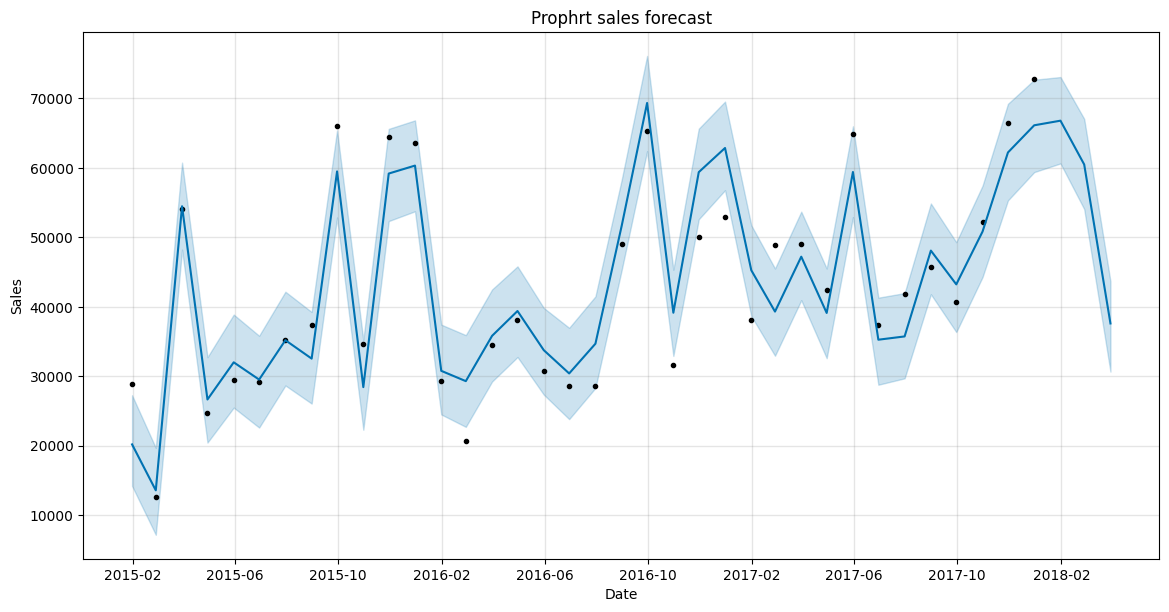

In [476]:
# Plot the forecast with Prophet's built-in trend and seasonality breakdown
fig=p_model.plot(p_pred)
fig.set_size_inches(12,6)
plt.title("Prophrt sales forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.savefig("../Charts/prophet_sales_forecast")
plt.show()

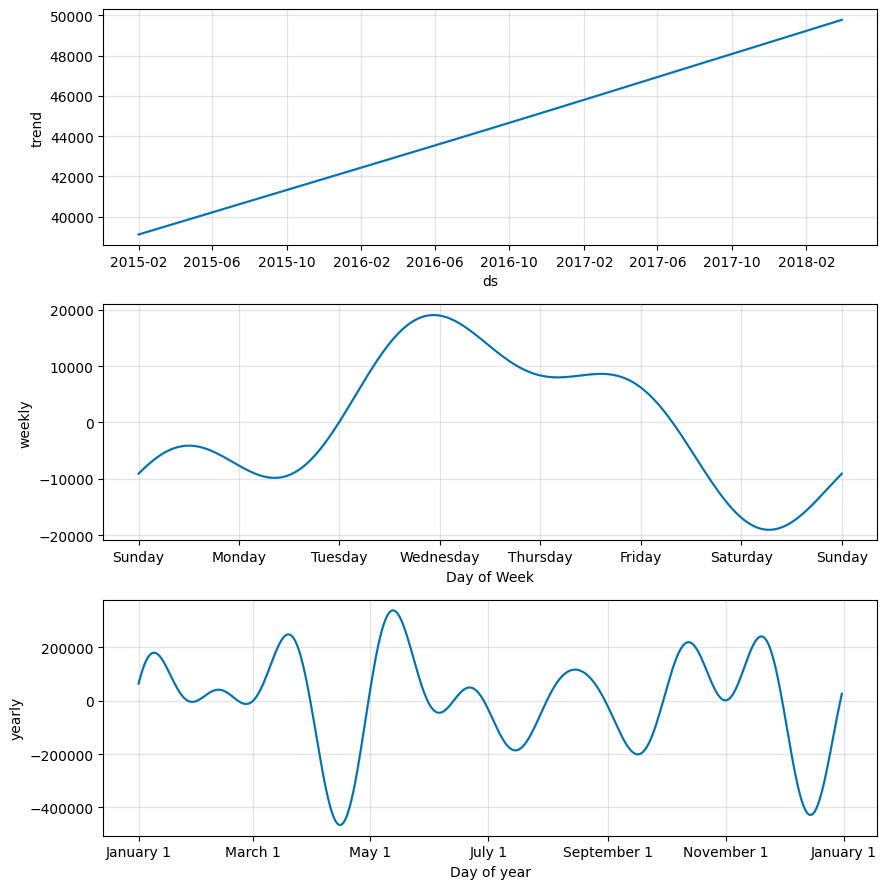

In [477]:
# Extract and interpret the weekly and yearly seasonality components
fig = p_model.plot_components(p_pred)
plt.savefig("../Charts/prophet_seasonal_breakdown")
plt.show()

**Extract and interpret the weekly and yearly seasonality components**
<br><br>
**Weekly**
<br>
* Sales increases in saturday and maximum in sunday
* There is a less sales on working days
<br><br>
**Yearly**
<br><br>
* Sales are more in begining and ending of the year 
* Less sales(combared to other months) are in mid of the year

<H3>XGBoost for Time Series (ML-based Approach)</H3>

In [478]:
# Start from the same canonical monthly series (numeric, one row per month)
monthly_xg = train_df.set_index("Order Date")["Sales"].resample("ME").sum().reset_index()
monthly_xg.columns = ["Order Date", "Sales"]

# Build lag / rolling features on the MONTHLY series (not the raw order-level rows)
monthly_xg["lag1"] = monthly_xg["Sales"].shift(1)
monthly_xg["lag2"] = monthly_xg["Sales"].shift(2)
monthly_xg["lag3"] = monthly_xg["Sales"].shift(3)
monthly_xg["rolling_mean3"] = monthly_xg["Sales"].rolling(3).mean()  

monthly_xg["Month"]   = monthly_xg["Order Date"].dt.month
monthly_xg["Quarter"] = monthly_xg["Order Date"].dt.quarter
monthly_xg["Season"]  = monthly_xg["Month"].apply(get_season)

# Drop the first few rows where lag/rolling features are NaN
monthly_xg = monthly_xg.dropna().reset_index(drop=True)

In [479]:
# Encode Season (only categorical column left)
le=LabelEncoder()
monthly_xg["Season"] = le.fit_transform(monthly_xg["Season"])

In [480]:
# Split using the SAME 12-month holdout as SARIMA/Prophet
x = monthly_xg.drop(columns=["Order Date", "Sales"])
y = monthly_xg["Sales"]

In [481]:
# Split data 
x_train = x[:-12]
x_test  = x[-12:]
y_train = y[:-12]
y_test  = y[-12:]

x_test3 = x_test[:3]
y_test3 = y_test[:3]

In [482]:
xg_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
xg_model.fit(x_train, y_train)
xg_pred = xg_model.predict(x_test)
xg_pred3=xg_pred[:3]

In [483]:
# Validation
xg_mse=mean_squared_error(y_test,xg_pred)
xg_mae=mean_absolute_error(y_test,xg_pred)
xg_mape=mean_absolute_percentage_error(y_test,xg_pred)

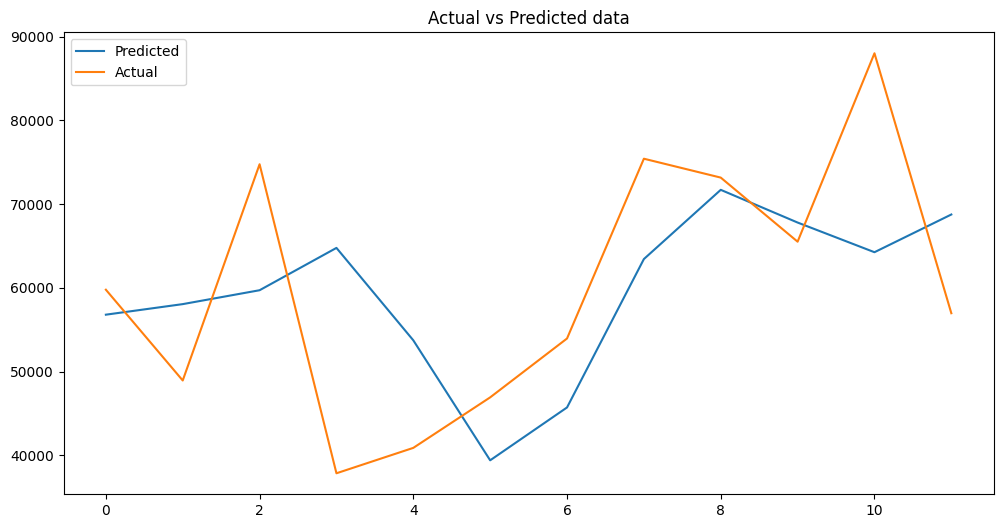

In [484]:
# Plot actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(xg_pred,label="Predicted")
plt.plot(y_test.values,label="Actual")
plt.title("Actual vs Predicted data")
plt.legend()
plt.savefig("../Charts/Actual_vs_predicted_xg_model")
plt.show()

<h3>Model Comparison Table (Required)</h3>

In [485]:
Val_table=pd.DataFrame({
    "Model":["Sarima","Prophet","XGBRegressor"],
    "MAE":[s_mae,p_mae,xg_mae],
    "MSE":[s_mse,p_mse,xg_mse],
    "MPSE":[s_mape,p_mape,xg_mape],
    "Forecast for Month 1":[s_pred[0],p_pred3["yhat"].iloc[-3],xg_pred3[0]],
    "Forecast for Month 2":[s_pred[1],p_pred3["yhat"].iloc[-2],xg_pred3[1]],
    "Forecast for Month 3":[s_pred[2],p_pred3["yhat"].iloc[-1],xg_pred3[2]]


})

In [486]:
Val_table.sort_values(by="MAE",ascending=True)

,Model,MAE,MSE,MPSE,Forecast for Month 1,Forecast for Month 2,Forecast for Month 3
0,Sarima,4807.958389,3.842526e+07,0.087875,60088.833267,58785.000740,70502.658240
2,XGBRegressor,11159.378742,1.821458e+08,0.205504,56785.968750,58046.480469,59705.257812
1,Prophet,18572.713412,5.210884e+08,0.283481,66779.537023,60476.050121,37590.146307


In [487]:
Val_table.sort_values(by="MSE",ascending=True)

,Model,MAE,MSE,MPSE,Forecast for Month 1,Forecast for Month 2,Forecast for Month 3
0,Sarima,4807.958389,3.842526e+07,0.087875,60088.833267,58785.000740,70502.658240
2,XGBRegressor,11159.378742,1.821458e+08,0.205504,56785.968750,58046.480469,59705.257812
1,Prophet,18572.713412,5.210884e+08,0.283481,66779.537023,60476.050121,37590.146307


In [488]:
Val_table.sort_values(by="MPSE",ascending=True)

,Model,MAE,MSE,MPSE,Forecast for Month 1,Forecast for Month 2,Forecast for Month 3
0,Sarima,4807.958389,3.842526e+07,0.087875,60088.833267,58785.000740,70502.658240
2,XGBRegressor,11159.378742,1.821458e+08,0.205504,56785.968750,58046.480469,59705.257812
1,Prophet,18572.713412,5.210884e+08,0.283481,66779.537023,60476.050121,37590.146307


<h2>Model : SARIMA </h2>

* **Model is considered to be best model if it have lowest MAE,MSE,MPSE**
* **SARIMA model is consisered best for this Dataset**

<h2> Product Category & Region Level Forecasting</h2>

In [489]:
# Furniture
furniture = train_df[train_df["Category"] == "Furniture"]
fSeg=(furniture.set_index("Order Date")["Sales"].resample("ME").sum())
f_train=fSeg[:-12]
f_test=fSeg[-12:]
s_model=SARIMAX(
    f_train,
    order=(0,1,1),
    seasonal_order=(0,1,1,12)
)
f_fit=s_model.fit(disp=False)
f_pred=f_fit.forecast(steps=12)

# Technology
technology = train_df[train_df["Category"] == "Technology"]
tSeg=(technology.set_index("Order Date")["Sales"].resample("ME").sum())
t_train=tSeg[:-12]
t_test=tSeg[-12:]
s_model=SARIMAX(
    t_train,
    order=(0,1,1),
    seasonal_order=(0,1,1,12)
)
t_fit=s_model.fit(disp=False)
t_pred=t_fit.forecast(steps=12)

# Office Supplies
office = train_df[train_df["Category"] == "Office Supplies"]
oSeg=(office.set_index("Order Date")["Sales"].resample("ME").sum())
o_train=oSeg[:-12]
o_test=oSeg[-12:]
s_model=SARIMAX(
    o_train,
    order=(0,1,1),
    seasonal_order=(0,1,1,12)
)
o_fit=s_model.fit(disp=False)
o_pred=o_fit.forecast(steps=12)

# West
west = train_df[train_df["Region"] == "West"]
wSeg=(west.set_index("Order Date")["Sales"].resample("ME").sum())
w_train=wSeg[:-12]
w_test=wSeg[-12:]
s_model=SARIMAX(
    w_train,
    order=(0,1,1),
    seasonal_order=(0,1,1,12)
)
w_fit=s_model.fit(disp=False)
w_pred=w_fit.forecast(steps=12)

# East
east = train_df[train_df["Region"] == "East"]
eSeg=(east.set_index("Order Date")["Sales"].resample("ME").sum())
e_train=eSeg[:-12]
e_test=eSeg[-12:]
s_model=SARIMAX(
    e_train,
    order=(0,1,1),
    seasonal_order=(0,1,1,12)
)
e_fit=s_model.fit(disp=False)
e_pred=e_fit.forecast(steps=12)

In [490]:
f_pred

2018-01-31    23146.254925
2018-02-28    17648.493132
2018-03-31    24818.904173
2018-04-30    21009.475494
2018-05-31    26248.981220
2018-06-30    20366.692192
2018-07-31    22712.200763
2018-08-31    27231.425545
2018-09-30    29912.374656
2018-10-31    23189.680764
2018-11-30    29790.304098
2018-12-31    34354.324911
Freq: ME, Name: predicted_mean, dtype: float64

In [491]:
f_test[:3]

Order Date
2018-01-31    15630.9640
2018-02-28    16195.5064
2018-03-31    15541.3878
Freq: ME, Name: Sales, dtype: float64

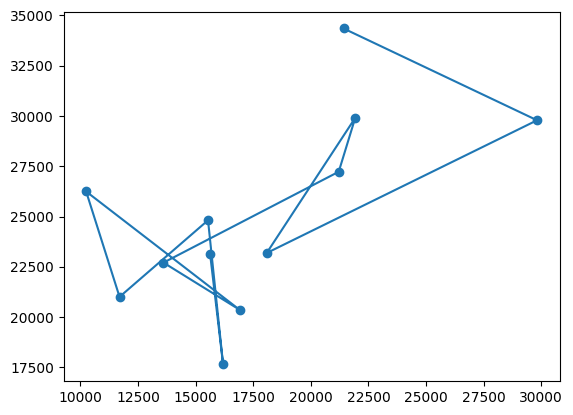

In [492]:
plt.plot(f_test, f_pred, marker='o', label='Furniture')


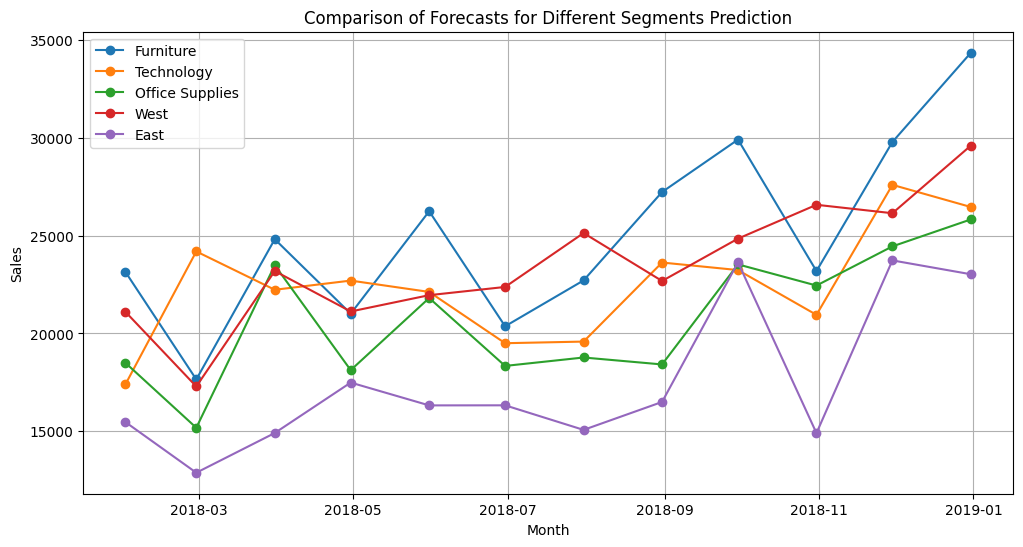

In [493]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(f_test.index, f_pred, marker='o', label='Furniture')
plt.plot(t_test.index, t_pred, marker='o', label='Technology')
plt.plot(o_test.index, o_pred, marker='o', label='Office Supplies')
plt.plot(w_test.index, w_pred, marker='o', label='West')
plt.plot(e_test.index, e_pred, marker='o', label='East')

plt.title("Comparison of Forecasts for Different Segments Prediction")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

* Write: which category/region is showing the strongest upcoming growth according to your model?
  * Furniture

<h3>Anomaly Detection in Sales Data</h3>

In [494]:
iso=IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)
weekly_sales["anomolies"]=iso.fit_predict(weekly_sales[["Sales"]])
anomolies=weekly_sales[weekly_sales["anomolies"]==-1]

In [495]:
anomolies

,Order Date,Sales,anomolies
7,2015-02-22,224.9120,-1
8,2015-03-01,102.9400,-1
11,2015-03-22,37703.6650,-1
28,2015-07-19,1387.6860,-1
31,2015-08-09,25207.1150,-1
46,2015-11-22,26793.6235,-1
55,2016-01-24,358.5220,-1
60,2016-02-28,1853.5410,-1
110,2017-02-12,31342.9950,-1
151,2017-11-26,27367.7160,-1


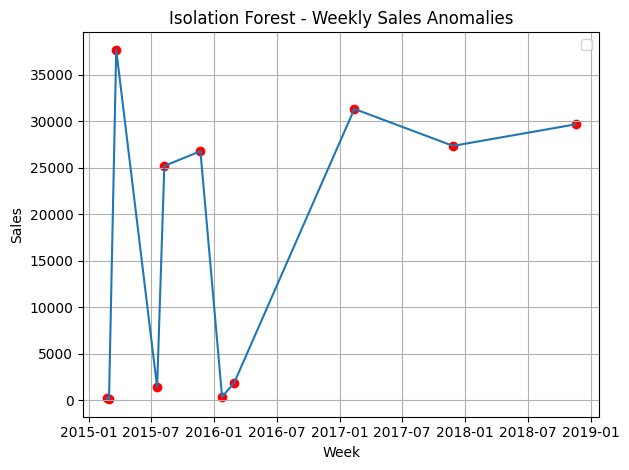

In [496]:
plt.plot(anomolies["Order Date"],anomolies["Sales"])
plt.scatter(anomolies["Order Date"],anomolies["Sales"],color="red")
plt.title("Isolation Forest - Weekly Sales Anomalies")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.legend()
plt.savefig("../Charts/Isolation Forest - Weekly Sales Anomalies")
plt.tight_layout()
plt.grid(True)
plt.show()



In [497]:
w=12
weekly_sales["Rolling_Mean"] = (
    weekly_sales["Sales"].rolling(w).mean()
)

weekly_sales["Rolling_STD"] = (
    weekly_sales["Sales"].rolling(w).std()
)

weekly_sales["Z_Score"] = (
    weekly_sales["Sales"] - weekly_sales["Rolling_Mean"]
) / weekly_sales["Rolling_STD"]

weekly_sales["Anomaly"] = (weekly_sales["Z_Score"] > 2) | (weekly_sales["Z_Score"] < -2) # we can use abs()
z_anomolies=weekly_sales[weekly_sales["Anomaly"]]

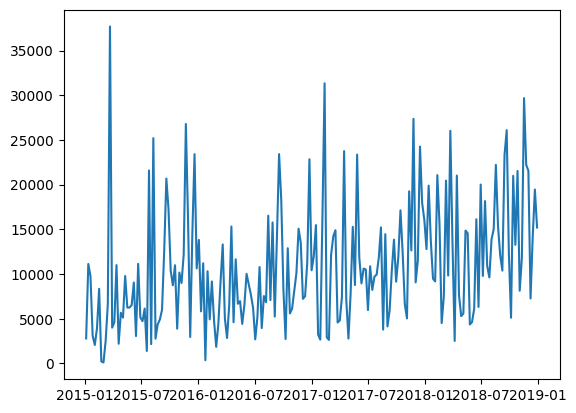

In [498]:
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"]
)

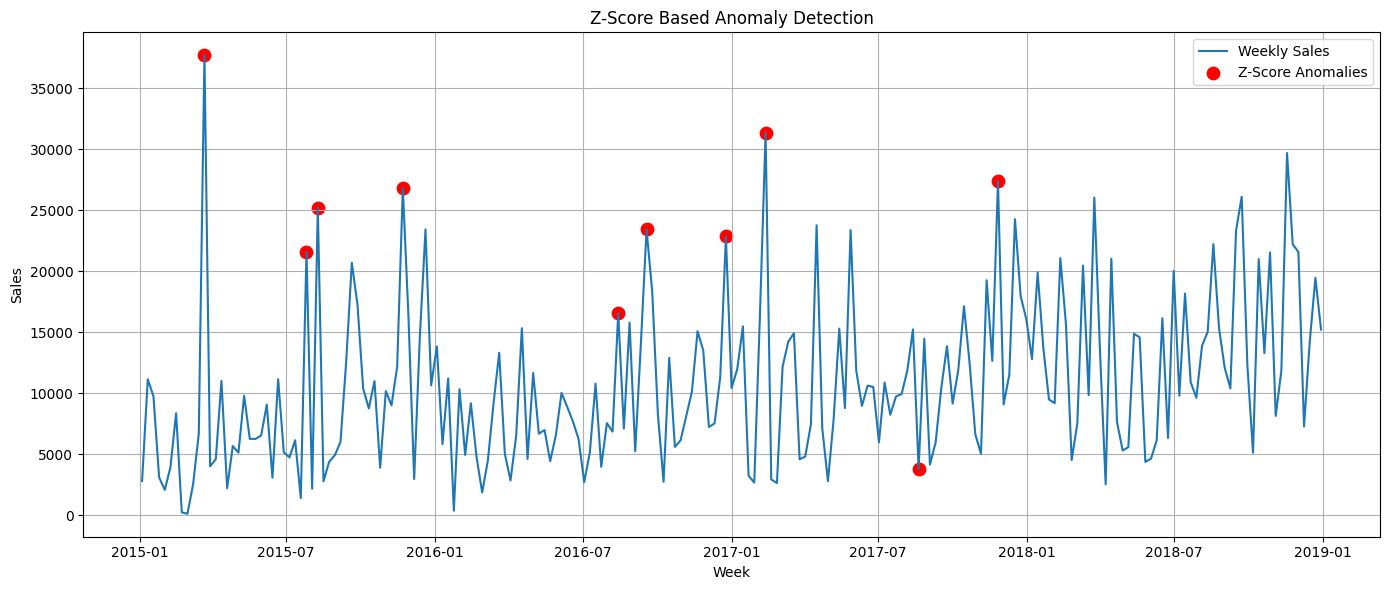

In [499]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

plt.scatter(
    z_anomolies["Order Date"],
    z_anomolies["Sales"],
    color="red",
    s=80,
    label="Z-Score Anomalies"
)

plt.title("Z-Score Based Anomaly Detection")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<h3>Product Demand Segmentation using Clustering</h3>

In [587]:
# 1. Total sales per sub-category
Total_sales = (
    train_df.groupby("Sub-Category")["Sales"]
    .sum()
    .reset_index(name="Total_sales")
)

# 2. Sales growth rate per sub-category (avg YoY % change)
yearly = (
    train_df.groupby(["Sub-Category", "Ordered Year"])["Sales"]
    .sum()
    .reset_index()
)
Sales_growth_rate = (
    yearly.sort_values(["Sub-Category", "Ordered Year"])
    .groupby("Sub-Category")["Sales"]
    .apply(lambda s: s.pct_change().mean())
    .reset_index(name="Sales_growth_rate")
)

# 3. Volatility (std of monthly sales) per sub-category
monthly_Sales = (
    train_df.groupby(["Sub-Category", pd.Grouper(key="Order Date", freq="ME")])["Sales"]
    .sum()
    .reset_index()
)
volatility = (
    monthly_Sales.groupby("Sub-Category")["Sales"]
    .std()
    .reset_index(name="Volatility")
)

# 4. Average order value per sub-category
avg_order = (
    monthly_Sales.groupby("Sub-Category")["Sales"]
    .mean()
    .reset_index(name="Average order")
)

# Merge everything explicitly on Sub-Category — no index alignment guesswork
sub_cat_features = (
    Total_sales
    .merge(Sales_growth_rate, on="Sub-Category", how="left")
    .merge(volatility, on="Sub-Category", how="left")
    .merge(avg_order, on="Sub-Category", how="left")
)

sub_cat_features = sub_cat_features.fillna(0)

In [601]:
X = sub_cat_features[
    ["Total_sales", "Sales_growth_rate", "Volatility", "Average order"]
]

In [602]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(X)

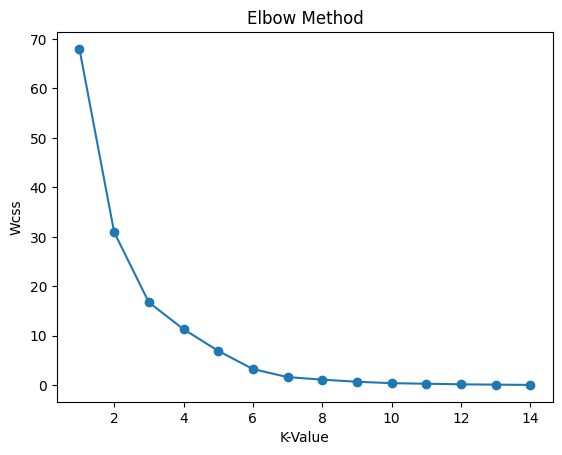

In [603]:
# Use the Elbow Method to find the optimal number of clusters
wcss=[]
for i in range(1,15):
    model=KMeans(n_clusters=i,random_state=42,n_init=10)
    model.fit(x_scaled)
    wcss.append(model.inertia_)

plt.plot(range(1,15),wcss,marker="o")
plt.title("Elbow Method")
plt.xlabel("K-Value")
plt.ylabel("Wcss")
plt.savefig("../Charts/Kmeans_Eblow_method")
plt.show()

* From the graph we can choose value of k as 3 or 4.
* We have to classify produts in a low ,medium and high demand.
* So, it is better to use k =3

In [604]:
# Apply K-Means Clustering to segment products into demand groups
model=KMeans(n_clusters=3,random_state=42,n_init=10)
cluster=model.fit_predict(x_scaled)

In [605]:
sub_cat_features["Demand"]=cluster

In [607]:
cluster_summary = sub_cat_features.groupby("Demand").mean(numeric_only=True)
print(cluster_summary)

          Total_sales  Sales_growth_rate   Volatility  Average order
Demand                                                              
0       221557.676125           0.251571  3349.886628    4873.976097
1        55331.883212           0.199589   808.150332    1154.913555
2        46420.308000           1.928448  2014.597320    1031.562400


In [608]:
sub_cat_features["Demand"]=sub_cat_features["Demand"].map({0:"High",1:"Medium",2:"Low"})

In [615]:
sub_cat_features

,Sub-Category,Total_sales,Sales_growth_rate,Volatility,Average order,Demand
0,Accessories,164186.7000,0.376381,2306.054626,3420.556250,High
1,Appliances,104618.4030,0.399276,1604.319614,2179.550062,Medium
2,Art,26705.4100,0.166056,297.338863,556.362708,Medium
3,Binders,200028.7850,0.218736,3296.318135,4167.266354,High
4,Bookcases,113813.1987,0.238065,2010.544909,2371.108306,Medium
5,Chairs,322822.7310,0.071358,3281.447487,6725.473563,High
6,Copiers,146248.0940,0.846718,5032.635056,4570.252938,High
7,Envelopes,16128.0460,-0.027666,235.208350,350.609696,Medium
8,Fasteners,3001.9600,0.157034,42.456486,65.260000,Medium
9,Furnishings,89212.0180,0.287889,1094.409778,1858.583708,Medium


In [625]:
sub_cat_features[["Sub-Category", "Demand"]].sort_values("Demand")

,Sub-Category,Demand
0,Accessories,High
14,Storage,High
13,Phones,High
11,Machines,High
6,Copiers,High
16,Tables,High
3,Binders,High
5,Chairs,High
15,Supplies,Low
4,Bookcases,Medium
